In [177]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [178]:
df=pd.read_csv("./dataset/ford_car_dataset (1).csv") 

In [179]:
print("First 10 Rows:")
print(df.head(10))
print("\nLast 5 Rows:")
print(df.tail())
print("\nDataset Shape:")
print(df.shape)
print("\nData Types:")
print(df.dtypes)

First 10 Rows:
     model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0   Fiesta  2017  12000    Automatic    15944   Petrol  150  57.7         1.0
1    Focus  2018  14000       Manual     9083   Petrol  150  57.7         1.0
2    Focus  2017  13000       Manual    12456   Petrol  150  57.7         1.0
3   Fiesta  2019  17500       Manual    10460   Petrol  145  40.3         1.5
4   Fiesta  2019  16500    Automatic     1482   Petrol  145  48.7         1.0
5   Fiesta  2015  10500       Manual    35432   Petrol  145  47.9         1.6
6     Puma  2019  22500       Manual     2029   Petrol  145  50.4         1.0
7   Fiesta  2017   9000       Manual    13054   Petrol  145  54.3         1.2
8     Kuga  2019  25500    Automatic     6894   Diesel  145  42.2         2.0
9    Focus  2018  10000       Manual    48141   Petrol  145  61.4         1.0

Last 5 Rows:
        model  year  price transmission  mileage fuelType  tax   mpg  \
17961   B-MAX  2017   8999       Manual  

In [180]:
# Observations:
# 1. The dataset contains details of used Ford cars.
# 2. Each row represents one car and its information.
# 3. Most columns contain numerical values, while model, transmission, and fuelType are text columns.
# 4. The dataset has enough records for analysis and prediction.
# 5. The price of a car can be predicted using the other columns.

In [181]:
print("Missing Values in Each Column:")
print(df.isnull().sum())
print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())
print("\nRemove duplicate rows:")
df = df.drop_duplicates()
print("\nShape After Removing Duplicates:")
print(df.shape)


Missing Values in Each Column:
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

Number of Duplicate Rows:
154

Remove duplicate rows:

Shape After Removing Duplicates:
(17812, 9)


In [182]:
# Observations:
# 1. No missing values were found in the dataset.
# 2. Duplicate rows were checked before analysis.
# 3. Duplicate records were removed using drop_duplicates().
# 4. The cleaned dataset is ready for further analysis.

In [183]:
print("Statistical Summary:")
print(df.describe())
print("\nPrice")
print("Minimum Price:", df["price"].min())
print("Maximum Price:", df["price"].max())
print("Mean Price:", df["price"].mean())
print("Median Price:", df["price"].median())
print("\nMileage")
print("Minimum Mileage:", df["mileage"].min())
print("Maximum Mileage:", df["mileage"].max())
print("Mean Mileage:", df["mileage"].mean())
print("Median Mileage:", df["mileage"].median())
print("\nYear")
print("Minimum Year:", df["year"].min())
print("Maximum Year:", df["year"].max())
print("Mean Year:", df["year"].mean())
print("Median Year:", df["year"].median())

Statistical Summary:
               year         price        mileage           tax           mpg  \
count  17812.000000  17812.000000   17812.000000  17812.000000  17812.000000   
mean    2016.862396  12269.556310   23381.146362    113.315012     57.908696   
std        2.052039   4736.285417   19419.011045     62.034603     10.132696   
min     1996.000000    495.000000       1.000000      0.000000     20.800000   
25%     2016.000000   8999.000000   10000.000000     30.000000     52.300000   
50%     2017.000000  11288.000000   18277.000000    145.000000     58.900000   
75%     2018.000000  15295.000000   31098.500000    145.000000     65.700000   
max     2060.000000  54995.000000  177644.000000    580.000000    201.800000   

         engineSize  
count  17812.000000  
mean       1.350623  
std        0.432581  
min        0.000000  
25%        1.000000  
50%        1.200000  
75%        1.500000  
max        5.000000  

Price
Minimum Price: 495
Maximum Price: 54995
Mean Price: 1

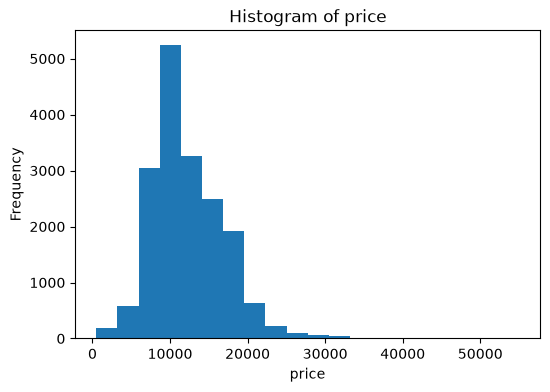

<Figure size 640x480 with 0 Axes>

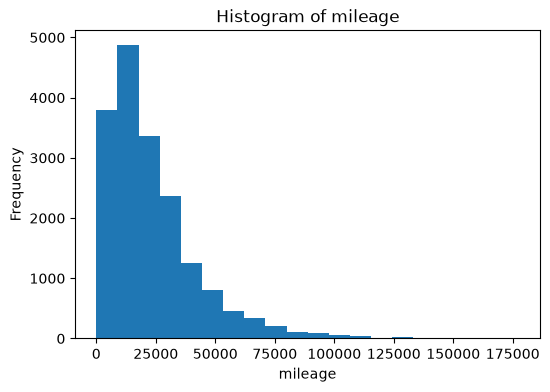

<Figure size 640x480 with 0 Axes>

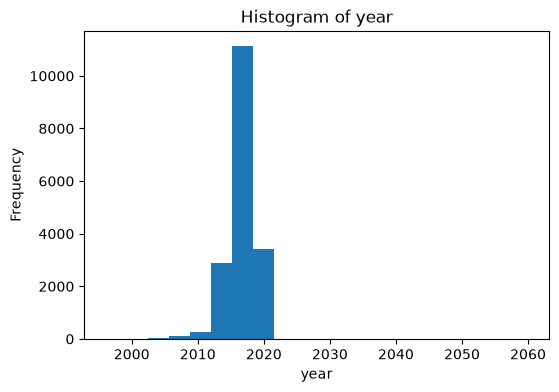

<Figure size 640x480 with 0 Axes>

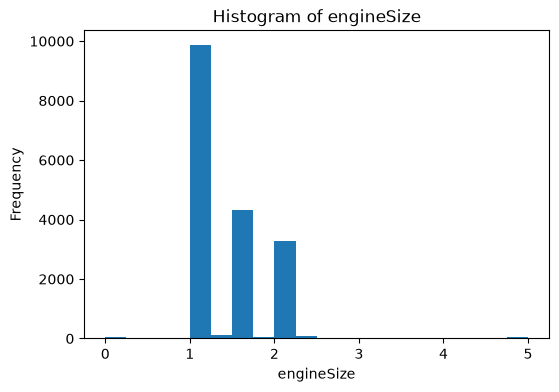

<Figure size 640x480 with 0 Axes>

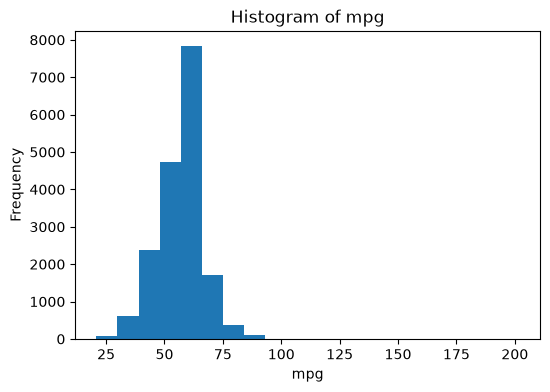

<Figure size 640x480 with 0 Axes>

In [184]:
def plot_histogram(column):
    plt.figure(figsize=(6,4))
    plt.hist(df[column], bins=20)
    plt.title("Histogram of " + column)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()
    plt.tight_layout()

plot_histogram("price")
plot_histogram("mileage")
plot_histogram("year")
plot_histogram("engineSize")
plot_histogram("mpg")

In [185]:
# Observations:
# 1. Price: Most cars are available at lower prices.
# 2. Mileage: Cars with low and medium mileage are more common.
# 3. Year: Most cars belong to recent manufacturing years.
# 4. Engine Size: Smaller engine sizes appear more frequently.
# 5. MPG: Most cars have average fuel efficiency.

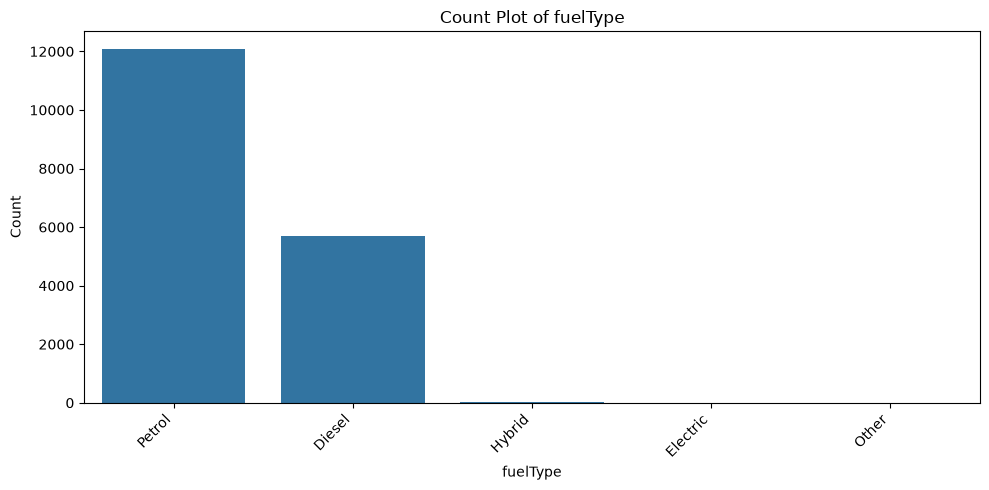

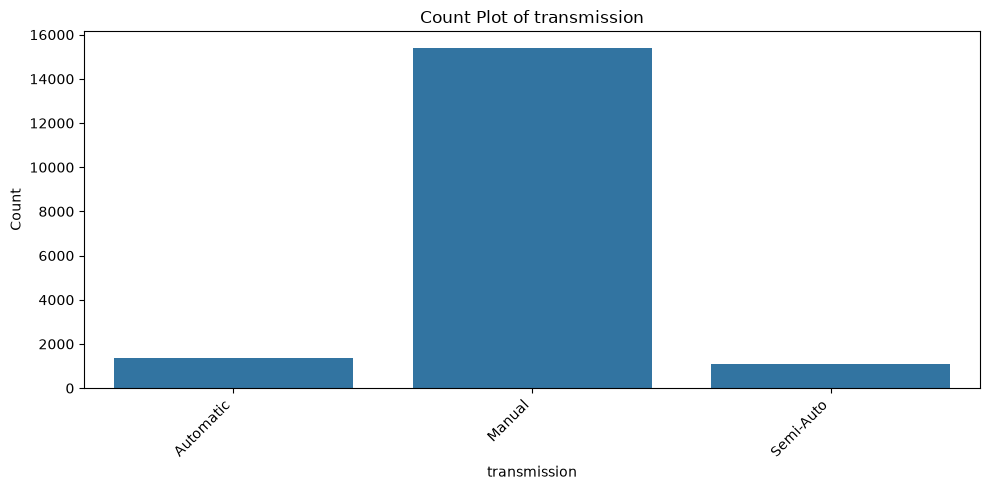

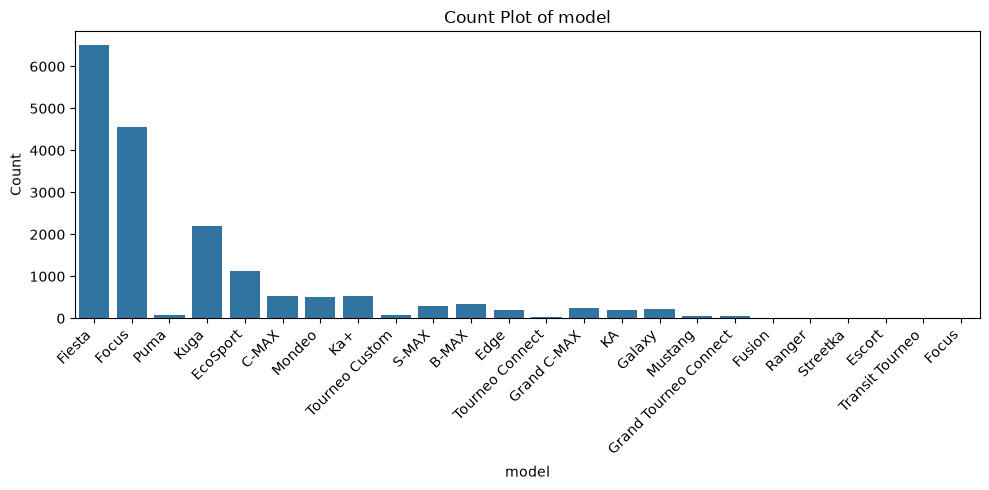

In [186]:
def count_plot(column):
    plt.figure(figsize=(10,5))
    sns.countplot(x=column, data=df)
    plt.title("Count Plot of " + column)
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
count_plot("fuelType")
count_plot("transmission")
count_plot("model")

In [187]:
# Insights from count plots:
#  Fuel Type Trend:
# Petrol vehicles dominate the market, indicating strong consumer preference for conventional engines.
# Diesel and hybrid options appear less frequent, suggesting limited adoption of alternative fuels.

#  Transmission Trend:
# Manual transmission is most common, showing that buyers still favor traditional driving control.
# Automatic transmission counts are rising but remain secondary, hinting at gradual modernization.

#Model Trend:
# A few models (like Fiesta and Focus) have very high counts, showing strong brand loyalty and market concentration.
# Many other models have low counts, implying niche appeal or limited production runs.
# This skewed distribution suggests that the market is driven by a handful of popular models rather than broad diversity.


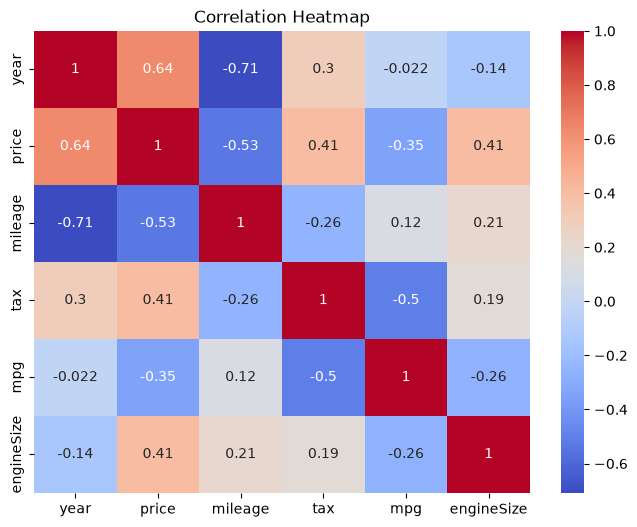

In [188]:
correlation = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [189]:
# Observations:
# 1. Price has a positive correlation with year.
# 2. Price has a negative correlation with mileage.
# 3. Engine size shows a positive correlation with price.
# 4. MPG has a weak negative correlation with price.
# 5. Year and mileage are the features most related to price.

In [190]:
input = [ "model","year","transmission","mileage","fuelType","tax","mpg","engineSize"]
output = "price"
print("Input Features:")
print(input)
print("\nTarget Feature:")
print(output)

Input Features:
['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize']

Target Feature:
price


In [191]:
print("Before Encoding:")
print(df[["fuelType", "transmission"]].head())
encoded_df = pd.get_dummies(df, columns=["fuelType", "transmission"])
print("\nAfter Encoding:")
print(encoded_df.head())

Before Encoding:
  fuelType transmission
0   Petrol    Automatic
1   Petrol       Manual
2   Petrol       Manual
3   Petrol       Manual
4   Petrol    Automatic

After Encoding:
     model  year  price  mileage  tax   mpg  engineSize  fuelType_Diesel  \
0   Fiesta  2017  12000    15944  150  57.7         1.0            False   
1    Focus  2018  14000     9083  150  57.7         1.0            False   
2    Focus  2017  13000    12456  150  57.7         1.0            False   
3   Fiesta  2019  17500    10460  145  40.3         1.5            False   
4   Fiesta  2019  16500     1482  145  48.7         1.0            False   

   fuelType_Electric  fuelType_Hybrid  fuelType_Other  fuelType_Petrol  \
0              False            False           False             True   
1              False            False           False             True   
2              False            False           False             True   
3              False            False           False             Tru

In [192]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
y = df[["year", "mileage", "tax", "mpg", "engineSize"]]
scaled_data = scaler.fit_transform(y)
scaled_df = pd.DataFrame(scaled_data, columns=y.columns)
print("First 5 Rows of Scaled Data:")
print(scaled_df.head())

First 5 Rows of Scaled Data:
       year   mileage       tax       mpg  engineSize
0  0.067059 -0.382994  0.591380 -0.020597   -0.810561
1  0.554393 -0.736317  0.591380 -0.020597   -0.810561
2  0.067059 -0.562616  0.591380 -0.020597   -0.810561
3  1.041726 -0.665405  0.510777 -1.737858    0.345325
4  1.041726 -1.127749  0.510777 -0.908836   -0.810561


Missing Values:

Duplicate Rows: 0

Shape after removing duplicates:
(17812, 9)
histogram function:


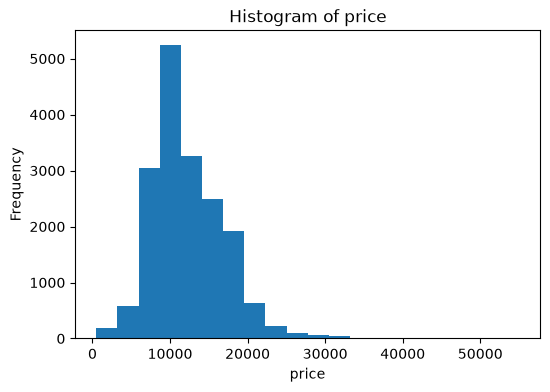

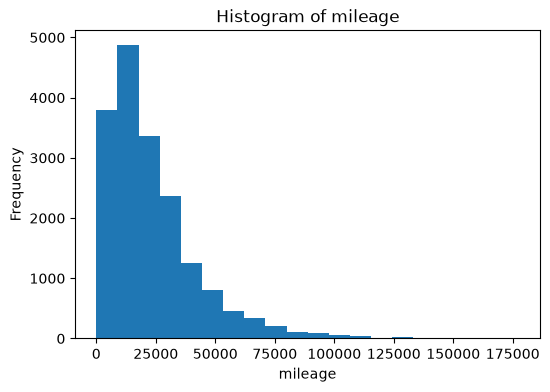

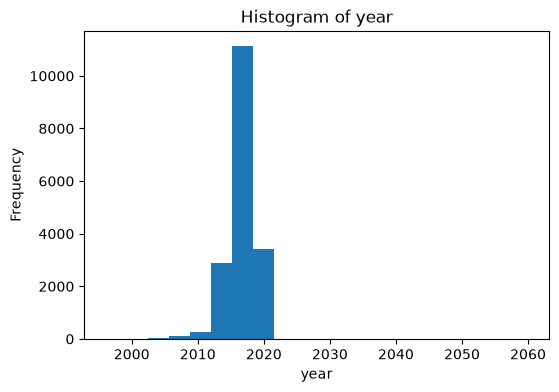

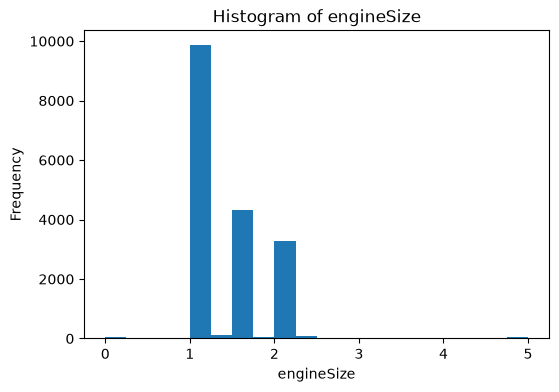

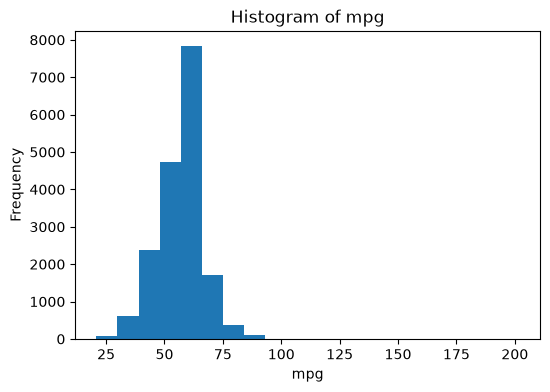

Count Plot Function


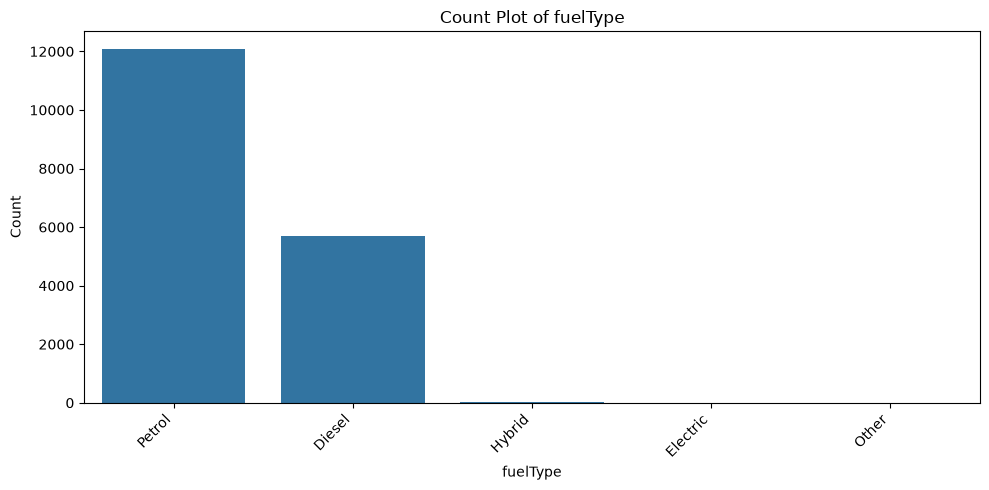

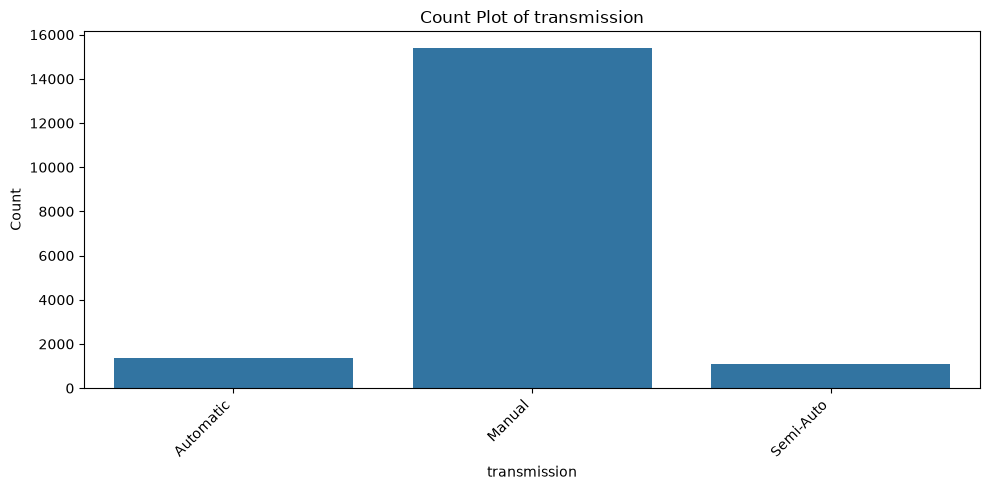

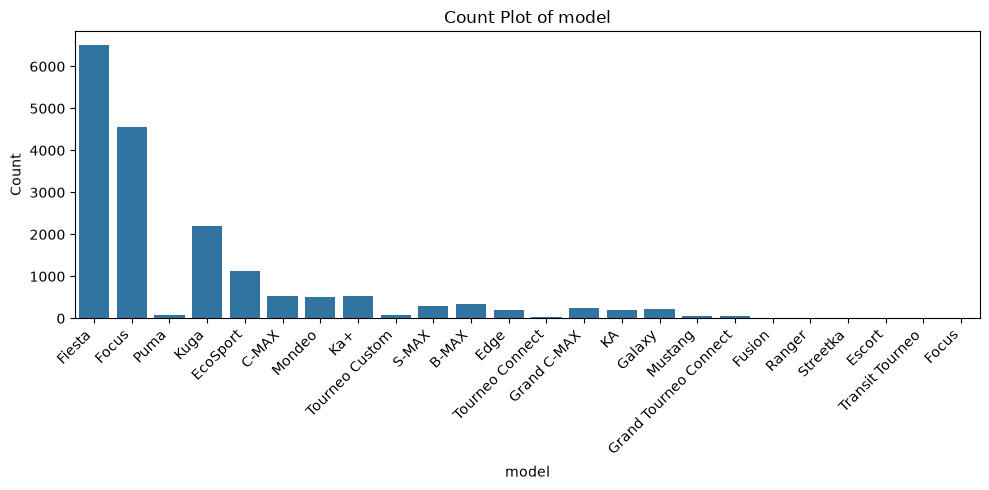

Correlation Heatmap


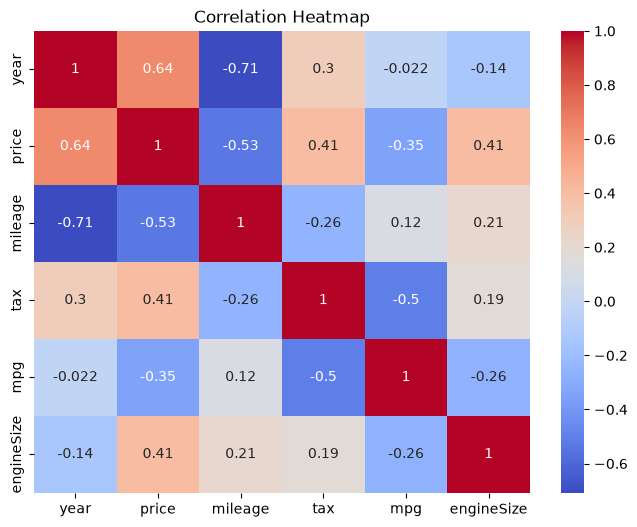

Input and Output Features

Input Features:
Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize'],
      dtype='str')

Output Feature:
price
One-Hot Encoding

Before Encoding:
  fuelType transmission
0   Petrol    Automatic
1   Petrol       Manual
2   Petrol       Manual
3   Petrol       Manual
4   Petrol    Automatic

After Encoding:
     model  year  price  mileage  tax   mpg  engineSize  fuelType_Diesel  \
0   Fiesta  2017  12000    15944  150  57.7         1.0            False   
1    Focus  2018  14000     9083  150  57.7         1.0            False   
2    Focus  2017  13000    12456  150  57.7         1.0            False   
3   Fiesta  2019  17500    10460  145  40.3         1.5            False   
4   Fiesta  2019  16500     1482  145  48.7         1.0            False   

   fuelType_Electric  fuelType_Hybrid  fuelType_Other  fuelType_Petrol  \
0              False            False           False             True   
1              

In [193]:
print("Missing Values:")
df.isnull().sum()
print("\nDuplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("\nShape after removing duplicates:")
print(df.shape)
print("histogram function:")

def histogram(column):
    plt.figure(figsize=(6,4))
    plt.hist(df[column], bins=20)
    plt.title("Histogram of " + column)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

histogram("price")
histogram("mileage")
histogram("year")
histogram("engineSize")
histogram("mpg")
print("Count Plot Function")
def count_plot(column):
    plt.figure(figsize=(10,5))
    sns.countplot(x=column, data=df)
    plt.title("Count Plot of " + column)
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

count_plot("fuelType")
count_plot("transmission")
count_plot("model")
print("Correlation Heatmap")
plt.figure(figsize=(8,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
print("Input and Output Features")
ip = df[["model","year","transmission","mileage","fuelType","tax","mpg","engineSize"]]
op= df["price"]
print("\nInput Features:")
print(ip.columns)
print("\nOutput Feature:")
print(op.name)
print("One-Hot Encoding")

print("\nBefore Encoding:")
print(df[["fuelType","transmission"]].head())
df_encoded = pd.get_dummies(df, columns=["fuelType","transmission"])
print("\nAfter Encoding:")
print(df_encoded.head())

In [194]:
# Display first 5 rows
print("First 10 rows")
print(df.head())
# Independent Features
X = df.drop("price", axis=1)
# Dependent Feature
y = df["price"]
# Shapes
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

First 10 rows
     model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0   Fiesta  2017  12000    Automatic    15944   Petrol  150  57.7         1.0
1    Focus  2018  14000       Manual     9083   Petrol  150  57.7         1.0
2    Focus  2017  13000       Manual    12456   Petrol  150  57.7         1.0
3   Fiesta  2019  17500       Manual    10460   Petrol  145  40.3         1.5
4   Fiesta  2019  16500    Automatic     1482   Petrol  145  48.7         1.0
Shape of X: (17812, 8)
Shape of y: (17812,)


In [195]:
# Identify categorical columns
categorical_columns = X.select_dtypes(include='object').columns
print("Categorical Columns:")
print(categorical_columns)
print("Before Encoding:")
print(X.head())
X_encoded = pd.get_dummies(X)
X_encoded = X_encoded.astype(int)
print("After Encoding:")
X_encoded.head()

Categorical Columns:
Index(['model', 'transmission', 'fuelType'], dtype='str')
Before Encoding:
     model  year transmission  mileage fuelType  tax   mpg  engineSize
0   Fiesta  2017    Automatic    15944   Petrol  150  57.7         1.0
1    Focus  2018       Manual     9083   Petrol  150  57.7         1.0
2    Focus  2017       Manual    12456   Petrol  150  57.7         1.0
3   Fiesta  2019       Manual    10460   Petrol  145  40.3         1.5
4   Fiesta  2019    Automatic     1482   Petrol  145  48.7         1.0
After Encoding:


C:\Users\lenovo\AppData\Local\Temp\ipykernel_120\1446724221.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include='object').columns


,year,mileage,tax,mpg,engineSize,model_ B-MAX,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Transit Tourneo,model_Focus,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
1,2018,9083,150,57,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
2,2017,12456,150,57,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
3,2019,10460,145,40,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
4,2019,1482,145,48,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1


In [196]:
from sklearn.preprocessing import StandardScaler

# Numerical columns
numerical_columns = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
# Create StandardScaler object
scaler = StandardScaler()
# Apply Standard Scaling
X_encoded[numerical_columns] = scaler.fit_transform(
    X_encoded[numerical_columns]
)

# After Scaling
print("\nAfter Scaling:")
X_encoded.head()


After Scaling:


,year,mileage,tax,mpg,engineSize,model_ B-MAX,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Transit Tourneo,model_Focus,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.067059,-0.382994,0.591380,-0.042291,-0.446958,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
1,0.554393,-0.736317,0.591380,-0.042291,-0.446958,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
2,0.067059,-0.562616,0.591380,-0.042291,-0.446958,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
3,1.041726,-0.665405,0.510777,-1.720193,-0.446958,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
4,1.041726,-1.127749,0.510777,-0.930592,-0.446958,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1


In [197]:
from sklearn.model_selection import train_test_split
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.33,
    random_state=42
)

# Display shapes
print("Shape of X_train:", X_train.shape)
print("Shape of X_test :", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test :", y_test.shape)

Shape of X_train: (11934, 37)
Shape of X_test : (5878, 37)
Shape of y_train: (11934,)
Shape of y_test : (5878,)


In [198]:
from sklearn.linear_model import LinearRegression
import pandas as pd
# Create the model
model = LinearRegression()
# Train the model
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](37,)","[ 2154.14,-1193.74, 0.61,..., 5944.08, -880.93,-3045.42]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](37,)","['year','mileage','tax',...,'fuelType_Hybrid','fuelType_Other', 'fuelType_Petrol']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.707e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,37
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(34)


In [199]:
print("Intercept:")
print(model.intercept_)
# Print Coefficients
print("\nCoefficients:")
print(model.coef_)
# Display feature names with coefficients
coef_df = pd.DataFrame({"Feature": X_train.columns,"Coefficient": model.coef_})
print("\nFeature Coefficients:")
print(coef_df)

Intercept:
17065.623926774817

Coefficients:
[ 2.15413822e+03 -1.19373708e+03  6.11630230e-01 -9.60320596e+02
  8.71118455e+02 -3.80736007e+03 -2.84000830e+03 -2.61884447e+03
  4.14193392e+03  1.09824561e+04 -2.97678853e+03 -8.83163121e+02
 -4.24374923e+02  2.08211122e+03 -2.63469775e+03  3.71226167e+02
 -4.51147833e+03 -6.85206461e+03 -5.47755651e+02 -1.61182353e+03
  9.56677861e+03  3.62774229e+03  1.27204500e+03  1.55943502e+03
  1.16760722e+03 -3.86881734e+02  2.30296643e+03 -2.73112447e+03
 -4.24793654e+03  2.63672239e+02 -2.98050346e+02  3.43781069e+01
 -1.87043270e+03 -1.47297536e+02  5.94407799e+03 -8.80927895e+02
 -3.04541986e+03]

Feature Coefficients:
                         Feature   Coefficient
0                           year   2154.138219
1                        mileage  -1193.737081
2                            tax      0.611630
3                            mpg   -960.320596
4                     engineSize    871.118455
5                   model_ B-MAX  -3807.360067


In [200]:


# Make predictions
y_pred = model.predict(X_test)

# Display first 10 predicted values
print("First 10 Predicted Values:")
print(y_pred[:10])

# Display first 10 actual values
print("\nFirst 10 Actual Values:")
print(y_test.iloc[:10].values)

# Compare Actual vs Predicted
comparison = pd.DataFrame({"Actual Price": y_test.values,"Predicted Price": y_pred})

print("\nComparison of Actual and Predicted Prices:")
print(comparison.head(10))

First 10 Predicted Values:
[22211.67805925 15037.33325529 16540.89418284 11703.00963582
 10969.0479209  13173.2620971   5771.86802387 15120.43385544
  6449.34367325 12474.11814962]

First 10 Actual Values:
[22975 18000 18500  9985  7998 13990  5000 15450  6160 12495]

Comparison of Actual and Predicted Prices:
   Actual Price  Predicted Price
0         22975     22211.678059
1         18000     15037.333255
2         18500     16540.894183
3          9985     11703.009636
4          7998     10969.047921
5         13990     13173.262097
6          5000      5771.868024
7         15450     15120.433855
8          6160      6449.343673
9         12495     12474.118150


In [201]:
from sklearn.metrics import r2_score

# Calculate R² Score
r2 = r2_score(y_test, y_pred)

# Print the R² Score
print("R² Score:", r2)

R² Score: 0.8310659101766342


In [202]:
# Interpretation
# The R² score obtained is 0.83.
# This means the model explains 83% of the variation in the car prices.
# The model has learned the relationship between the input features and the target variable effectively.
# A higher R² value indicates better predictive performance.
# Since 0.83 is close to 1, the model provides accurate predictions for mos

In [203]:
import joblib
# Save the trained Linear Regression model
joblib.dump(model, "LR_ford_car.pkl")
# Save the StandardScaler
joblib.dump(scaler, "scaler.pkl")
# Save the encoded column names
joblib.dump(X_encoded.columns.tolist(), "columns.pkl")
print("Model and preprocessing objects saved successfully!")

Model and preprocessing objects saved successfully!
